# Metadata preprocessing and exploration

This notebook covers the loading, preprocessing, and exploratory analysis 
of the metadata associated with the seismic acceleration signals. 
The metadata describe the event and station characteristics, including 
epicentral distance, peak ground acceleration (PGA), and site classification.

## 1. Imports and visualization settings

In [82]:
from pathlib import Path
import pandas as pd
import numpy as np
from itertools import combinations
from scipy import stats
from IPython.display import display
from src import (build_metadata,
                 clean_metadata,
                 plot_column_types_pie,
                 plot_numerical_distributions,
                 plot_categorical_distributions,
                 plot_correlation_matrix,
                 plot_significant_corr_diff,
                 plot_station_map,
                 plot_pga_and_duration_by_component,
                 plot_pga_correlation_by_group,
                 set_plot_style,
                 corr_diff_to_latex,
                 metadata_table_to_latex,
                 constant_fields_to_latex)
import logging
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Data loading

Raw data are loaded from the zip archive containing the `.ASC` files. 
The function `build_metadata` extracts the metadata from the header 
of each file and returns a dataframe with one row per file.

In [83]:
# CONFIGURATION
DATA_TYPE = 'displacement'  # Options: 'acceleration', 'velocity', 'displacement'

In [84]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

# Define all paths from project root
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / '01_metadata' / DATA_TYPE
FIGURES_DIR = PROJECT_ROOT / 'figures' / '01_metadata' / DATA_TYPE
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / 'latex_tables'

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(DATA_PROCESSED.exists(), f"Processed data directory ready: {DATA_PROCESSED}")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/displacement
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables
INFO | Processed data directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01_metadata/displacement


In [85]:
# Load metadata
logger.info("Loading metadata...")

# Determine zip filename based on data type
if DATA_TYPE == 'acceleration':
    zip_filename = 'query_acc.zip'
elif DATA_TYPE == 'velocity':
    zip_filename = 'query_vel.zip'
elif DATA_TYPE == 'displacement':
    zip_filename = 'query_disp.zip'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

zip_path = DATA_RAW / zip_filename
df_meta = build_metadata(zip_path)

# Check if metadata was loaded successfully
check(df_meta is not None, "Metadata dataframe created")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata dataframe loaded, shape: {df_meta.shape}")

INFO | Loading metadata...
INFO | Metadata dataframe created
INFO | Metadata dataframe is not empty
INFO | Metadata dataframe loaded, shape: (66, 65)


In [86]:
output_path = LATEX_TABLES_DIR / f'header_table_{DATA_TYPE[:3]}.tex'
latex_table = metadata_table_to_latex(df_meta, output_path=output_path)

Saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables/header_table_dis.tex


### Codice per capire come citare il dataset nella tesi - DA CANCELLARE PRIMA DI LAST COMMIT

In [87]:
import pandas as pd

fields = [
    "DATA_LICENSE",
    "DATA_CITATION", 
    "DATA_CREATOR",
    "ORIGINAL_DATA_MEDIATOR_CITATION",
    "ORIGINAL_DATA_MEDIATOR",
    "ORIGINAL_DATA_CREATOR_CITATION",
    "ORIGINAL_DATA_CREATOR",
    "EVENT_ID",
    "EVENT_NAME",
    "EVENT_DATE_YYYYMMDD"
]

for field in fields:
    if field in df_meta.columns:
        values = df_meta[field].unique()
        print(f"\n{field}:")
        print(f"  Valori unici: {len(values)}")
        for v in values:
            print(f"    - {v}")
    else:
        print(f"\n{field}: CAMPO NON TROVATO")


DATA_LICENSE:
  Valori unici: 1
    - D (network default license)

DATA_CITATION:
  Valori unici: 1
    - Felicetta C., Russo E., D Amico M., Sgobba S., Lanzano G., Mascandola C., Pacor F., Luzi L. (2023) Italian Accelerometric Archive v 4.0 - Istituto Nazionale di Geofisica e Vulcanologia, Dipartimento della Protezione Civile Nazionale. doi: 10.13127/itaca.4.0

DATA_CREATOR:
  Valori unici: 1
    - ITACA working group

ORIGINAL_DATA_MEDIATOR_CITATION:
  Valori unici: 3
    - ingvran.int.ingv.it
    - 
    - webservices.ingv.it

ORIGINAL_DATA_MEDIATOR:
  Valori unici: 3
    - ingvran.int.ingv.it
    - http://ws.resif.fr/
    - webservices.ingv.it

ORIGINAL_DATA_CREATOR_CITATION:
  Valori unici: 4
    - Presidency Of Counsil Of Ministers-Civil Protection Department. (1972). Italian Strong Motion Network. Presidency of Counsil of Ministers - Civil Protection Department. https://doi.org/10.7914/SN/IT http://www.fdsn.org/networks/detail/IT/
    - RESIF. (1995). RESIF-RLBP French Broad-ban

## 3. Exploration (raw)

A first exploration of the raw metadata is performed to understand 
the structure of the dataset before preprocessing. The number of columns, 
data types, and missing values are inspected.

In [88]:
# Preview dataset
logger.info("Previewing dataset")

# Shape
print("Metadata DataFrame shape:", df_meta.shape)

# Columns
print("\nMetadata columns:")
for col in df_meta.columns:
    print(f"  {col}")

# Data types
print("\nColumn types distribution:")
print(df_meta.dtypes.value_counts())

# Missing values
print("Missing values (NaN) in raw df_meta:")
print(df_meta.isnull().sum().sum())

# Display dataset head
display(df_meta.head())

INFO | Previewing dataset


Metadata DataFrame shape: (66, 65)

Metadata columns:
  file
  EVENT_NAME
  EVENT_ID
  EVENT_DATE_YYYYMMDD
  EVENT_TIME_HHMMSS
  EVENT_LATITUDE_DEGREE
  EVENT_LONGITUDE_DEGREE
  EVENT_DEPTH_KM
  HYPOCENTER_REFERENCE
  MAGNITUDE_W
  MAGNITUDE_W_REFERENCE
  MAGNITUDE_L
  MAGNITUDE_L_REFERENCE
  FOCAL_MECHANISM
  NETWORK
  STATION_CODE
  STATION_NAME
  STATION_LATITUDE_DEGREE
  STATION_LONGITUDE_DEGREE
  STATION_ELEVATION_M
  LOCATION
  SENSOR_DEPTH_M
  VS30_M/S
  SITE_CLASSIFICATION_EC8
  MORPHOLOGIC_CLASSIFICATION
  EPICENTRAL_DISTANCE_KM
  EARTHQUAKE_BACKAZIMUTH_DEGREE
  DATE_TIME_FIRST_SAMPLE_YYYYMMDD_HHMMSS
  DATE_TIME_FIRST_SAMPLE_PRECISION
  SAMPLING_INTERVAL_S
  NDATA
  DURATION_S
  STREAM
  UNITS
  INSTRUMENT
  INSTRUMENT_ANALOG/DIGITAL
  INSTRUMENTAL_FREQUENCY_HZ
  INSTRUMENTAL_DAMPING
  FULL_SCALE_G
  N_BIT_DIGITAL_CONVERTER
  PGD_CM
  TIME_PGD_S
  BASELINE_CORRECTION
  FILTER_TYPE
  FILTER_ORDER
  LOW_CUT_FREQUENCY_HZ
  HIGH_CUT_FREQUENCY_HZ
  LATE/NORMAL_TRIGGERED
  DATABASE_

,file,EVENT_NAME,EVENT_ID,EVENT_DATE_YYYYMMDD,EVENT_TIME_HHMMSS,EVENT_LATITUDE_DEGREE,EVENT_LONGITUDE_DEGREE,EVENT_DEPTH_KM,HYPOCENTER_REFERENCE,MAGNITUDE_W,...,DATA_CREATOR,ORIGINAL_DATA_MEDIATOR_CITATION,ORIGINAL_DATA_MEDIATOR,ORIGINAL_DATA_CREATOR_CITATION,ORIGINAL_DATA_CREATOR,USER1,USER2,USER3,USER4,USER5
0,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,None,INT-41004391,20241209,104121,44.5127,6.8533,10.4,INGV-BULLETIN,3.8,...,ITACA working group,ingvran.int.ingv.it,ingvran.int.ingv.it,Presidency Of Counsil Of Ministers-Civil Prote...,network: IT (Italian Strong Motion Network (RA...,,,,,
1,query_disp/FR.REVF.00.HNZ.D.INT-41004391.DIS.M...,None,INT-41004391,20241209,104121,44.5127,6.8533,10.4,INGV-BULLETIN,3.8,...,ITACA working group,,http://ws.resif.fr/,RESIF. (1995). RESIF-RLBP French Broad-band ne...,network: FR (RESIF and other broad-band and ac...,,,,,
2,query_disp/FR.EILF.00.HNE.D.INT-41004391.DIS.M...,None,INT-41004391,20241209,104121,44.5127,6.8533,10.4,INGV-BULLETIN,3.8,...,ITACA working group,,http://ws.resif.fr/,RESIF. (1995). RESIF-RLBP French Broad-band ne...,network: FR (RESIF and other broad-band and ac...,,,,,
3,query_disp/FR.MON.00.HNZ.D.INT-41004391.DIS.MP...,None,INT-41004391,20241209,104121,44.5127,6.8533,10.4,INGV-BULLETIN,3.8,...,ITACA working group,,http://ws.resif.fr/,RESIF. (1995). RESIF-RLBP French Broad-band ne...,network: FR (RESIF and other broad-band and ac...,,,,,
4,query_disp/GU.BHB..HNE.D.INT-41004391.DIS.MP.ASC,None,INT-41004391,20241209,104121,44.5127,6.8533,10.4,INGV-BULLETIN,3.8,...,ITACA working group,webservices.ingv.it,webservices.ingv.it,University Of Genova. (1967). Regional Seismic...,network: GU (Regional Seismic Network of North...,,,,,


`isnull()` returns 0 for all columns because missing values are encoded as empty strings `''` or the string `'None'`, not as `NaN`. This will be addressed in the preprocessing step.

In [89]:
# Check which columns have only one unique value
constant_cols = [col for col in df_meta.columns if df_meta[col].nunique() == 1]
logger.info(f"Found {len(constant_cols)} constant columns")

# Create LaTeX table
latex_table = constant_fields_to_latex(
    df_meta, 
    constant_cols, 
    output_path=LATEX_TABLES_DIR / f'constant_fields_{DATA_TYPE[:3]}.tex'
)

INFO | Found 38 constant columns


Saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables/constant_fields_dis.tex


## 4. Preprocessing

The raw metadata are preprocessed through the following steps:

1. **Missing value replacement** — empty strings and `'None'` values are replaced with `NaN`
2. **Column dropping** — columns that are constant, empty, or irrelevant are removed
3. **Type conversion** — numerical columns are converted to `float64` or `int64`, 
   date columns are converted to `datetime`
4. **String normalization** — leading and trailing whitespace is removed from string columns
5. **Duplicate removal** — duplicate rows are removed

In [90]:
logger.info("Starting metadata cleaning...")
df_meta_clean = clean_metadata(df_meta)
check(df_meta_clean is not None, "Cleaning returned a dataframe")
check(len(df_meta_clean) > 0, "Cleaned dataset is not empty")
logger.info(f"Cleaning completed. Shape of cleaned dataset: {df_meta_clean.shape}")

INFO | Starting metadata cleaning...
INFO | Cleaning returned a dataframe
INFO | Cleaned dataset is not empty
INFO | Cleaning completed. Shape of cleaned dataset: (66, 38)


## 5. Post-preprocessing check

The preprocessed dataframe is inspected to verify that the preprocessing 
steps have been applied correctly. The number of remaining columns, 
data types, and missing values are checked.

INFO | Post-preprocessing checks


Cleaned metadata dataframe shape: (66, 38)

Number of columns per type:
object            19
float64           14
int64              3
datetime64[ns]     2
Name: count, dtype: int64
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/displacement/column_types_distribution_dis.pdf


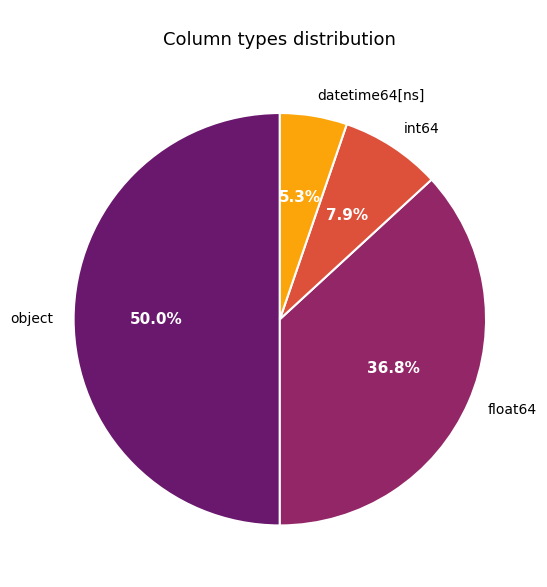

INFO | No empty strings remaining
INFO | NaN ratio OK: 0.01



Number of missing values after preprocessing for each column:
SITE_CLASSIFICATION_EC8    31.82
LOCATION                   22.73


In [91]:
logger.info("Post-preprocessing checks")
# Shape after preprocessing
print("Cleaned metadata dataframe shape:", df_meta_clean.shape)

# Number of columns per type
print("\nNumber of columns per type:")
print(df_meta_clean.dtypes.value_counts())

# Pie chart of column types
plot_column_types_pie(
    df_meta_clean, 
    output_dir=FIGURES_DIR,
    filename=f'column_types_distribution_{DATA_TYPE[:3]}.pdf'
)

# Number of missing values after preprocessing
print("\nNumber of missing values after preprocessing for each column:")
missing = df_meta_clean.isnull().mean().sort_values(ascending=False) * 100
print(missing[missing > 0].round(2).to_string())

empty_strings = (df_meta_clean == '').sum().sum()
check(empty_strings == 0, "No empty strings remaining")

nan_ratio = df_meta_clean.isna().mean().mean()

if nan_ratio > 0.2:
    logger.warning(f"High NaN ratio: {nan_ratio:.2f}")
else:
    logger.info(f"NaN ratio OK: {nan_ratio:.2f}")


In [92]:
# Numerical columns
print("Numerical columns:")
print(df_meta_clean.select_dtypes(include=['float64', 'int64']).columns.tolist())

Numerical columns:
['EVENT_LATITUDE_DEGREE', 'EVENT_LONGITUDE_DEGREE', 'EVENT_DEPTH_KM', 'MAGNITUDE_W', 'STATION_LATITUDE_DEGREE', 'STATION_LONGITUDE_DEGREE', 'STATION_ELEVATION_M', 'SENSOR_DEPTH_M', 'EPICENTRAL_DISTANCE_KM', 'EARTHQUAKE_BACKAZIMUTH_DEGREE', 'SAMPLING_INTERVAL_S', 'NDATA', 'DURATION_S', 'INSTRUMENTAL_FREQUENCY_HZ', 'FILTER_ORDER', 'LOW_CUT_FREQUENCY_HZ', 'HIGH_CUT_FREQUENCY_HZ']


In [93]:
# Categorical columns
print("Categorical columns:")
print(df_meta_clean.select_dtypes(include='object').columns.tolist())

Categorical columns:
['file', 'EVENT_ID', 'HYPOCENTER_REFERENCE', 'MAGNITUDE_W_REFERENCE', 'FOCAL_MECHANISM', 'NETWORK', 'STATION_CODE', 'STATION_NAME', 'LOCATION', 'SITE_CLASSIFICATION_EC8', 'STREAM', 'INSTRUMENT', 'INSTRUMENT_ANALOG/DIGITAL', 'PGD_CM', 'TIME_PGD_S', 'BASELINE_CORRECTION', 'FILTER_TYPE', 'LATE/NORMAL_TRIGGERED', 'PROCESSING']


## 6. Metadata exploration (post-preprocessing)

Exploratory analysis of the preprocessed metadata. Distributions of 
numerical and categorical variables are visualized. A correlation matrix 
is computed to identify linear relationships between numerical variables. 
The Pearson correlation coefficient between two variables $x$ and $y$ is defined as:

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

A station map is produced to visualize the spatial distribution of the 
recording stations relative to the epicenter.

In [94]:
# Check which columns have only one unique value
constant_cols = [col for col in df_meta_clean.columns if df_meta_clean[col].nunique() == 1]
logger.info(f"Found {len(constant_cols)} constant columns")

# Create LaTeX table
latex_table = constant_fields_to_latex(
    df_meta_clean, 
    constant_cols, 
    output_path=LATEX_TABLES_DIR / f'constant_fields_after_preprocessing_{DATA_TYPE[:3]}.tex'
)

INFO | Found 17 constant columns


Saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables/constant_fields_after_preprocessing_dis.tex


Since the dataset contains recordings from a single seismic event, many columns are constant across all files (e.g. event coordinates, magnitude, focal mechanism).  We create a reduced dataframe with only the varying columns, useful for analysis and visualization.

In [95]:
constant_cols = [col for col in df_meta_clean.columns if df_meta_clean[col].nunique() == 1]
df_meta_var = df_meta_clean.drop(columns=constant_cols)
df_meta_var = df_meta_var.copy()
df_meta_var['PGA_CM/S^2'] = df_meta_var['PGA_CM/S^2'].abs()

# Check if PGA column is present
check(len(df_meta_var.columns) > 0, "Variable dataframe is not empty")
check('PGA_CM/S^2' in df_meta_var.columns, "Target column present")
logger.info(f"Variable dataframe ready, shape: {df_meta_var.shape}")

KeyError: 'PGA_CM/S^2'

### Numerical distributions

Histograms of the numerical variables in the preprocessed metadata.

INFO | Plotting numerical distributions
INFO | Found 12 numerical columns: ['STATION_LATITUDE_DEGREE', 'STATION_LONGITUDE_DEGREE', 'STATION_ELEVATION_M', 'SENSOR_DEPTH_M', 'EPICENTRAL_DISTANCE_KM', 'EARTHQUAKE_BACKAZIMUTH_DEGREE', 'NDATA', 'DURATION_S', 'PGA_CM/S^2', 'TIME_PGA_S', 'LOW_CUT_FREQUENCY_HZ', 'HIGH_CUT_FREQUENCY_HZ']


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/numerical_distributions_acc.pdf


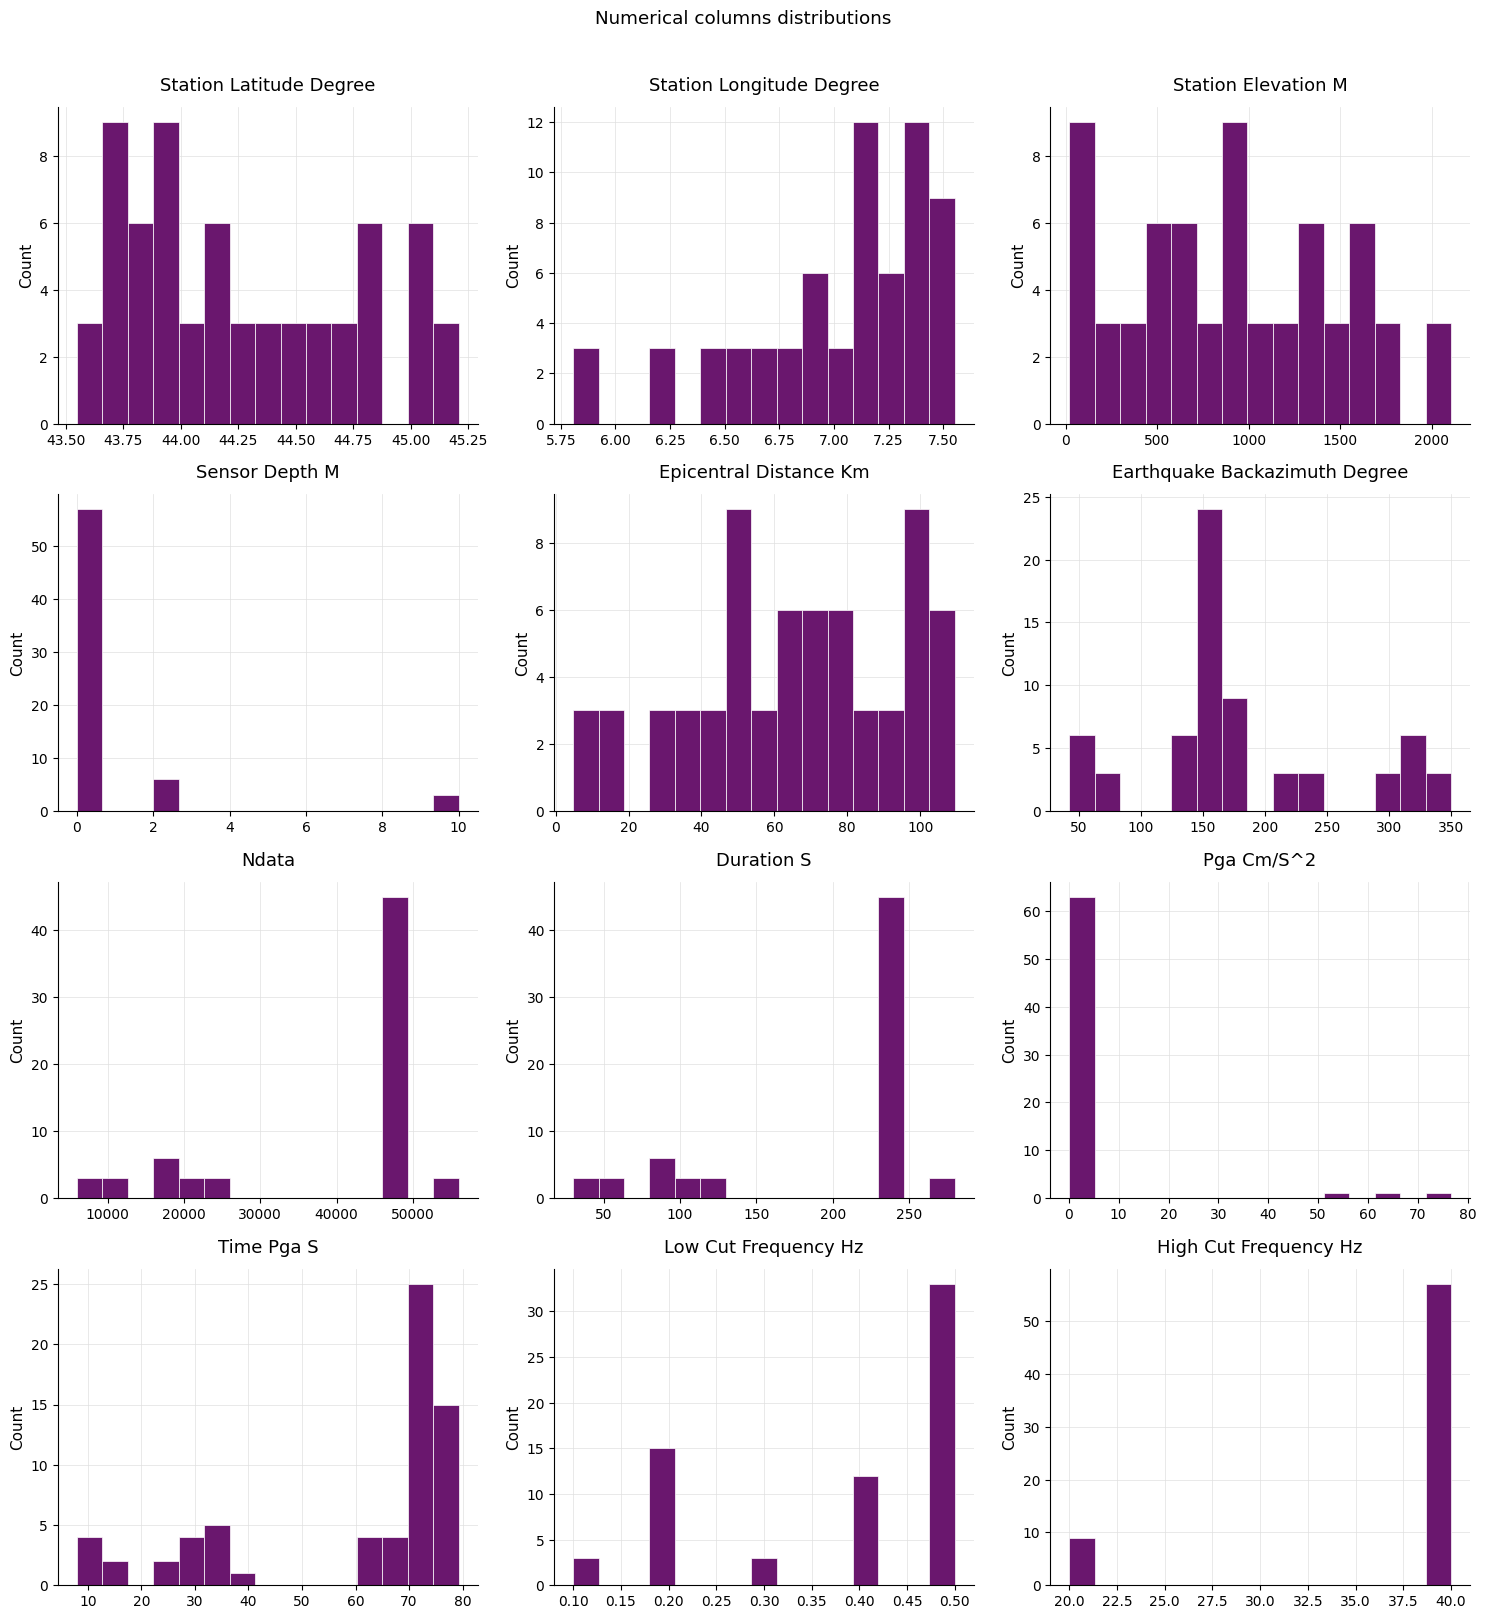

In [ ]:
logger.info("Plotting numerical distributions")

# Find numerical columns automatically
num_cols = df_meta_var.select_dtypes(include=['number']).columns.tolist()

# Optionally filter out unwanted columns
exclude_cols = ['file']
num_cols = [col for col in num_cols if col not in exclude_cols]

logger.info(f"Found {len(num_cols)} numerical columns: {num_cols}")

plot_numerical_distributions(
    df_meta_var, 
    num_cols, 
    output_dir=FIGURES_DIR,
    filename=f'numerical_distributions_{DATA_TYPE[:3]}.pdf'
)

### Categorical distributions

Bar charts of the categorical variables in the preprocessed metadata.

INFO | Plotting categorical distributions
INFO | Found 7 categorical columns: ['NETWORK', 'STATION_CODE', 'STATION_NAME', 'LOCATION', 'SITE_CLASSIFICATION_EC8', 'STREAM', 'INSTRUMENT']
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/categorical_distributions_few_acc.pdf


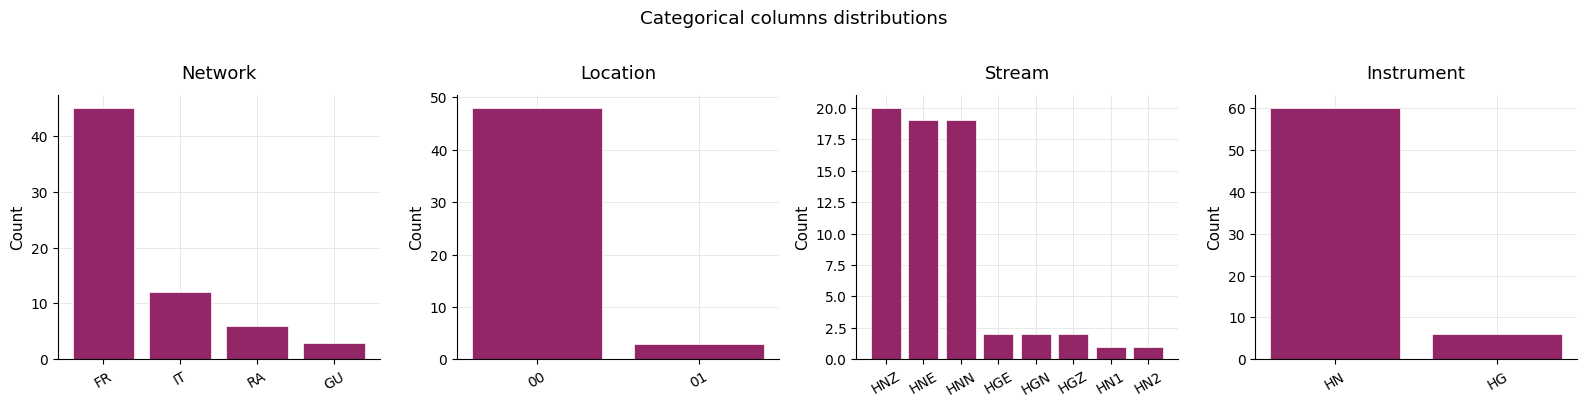

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/categorical_distributions_many_acc.pdf


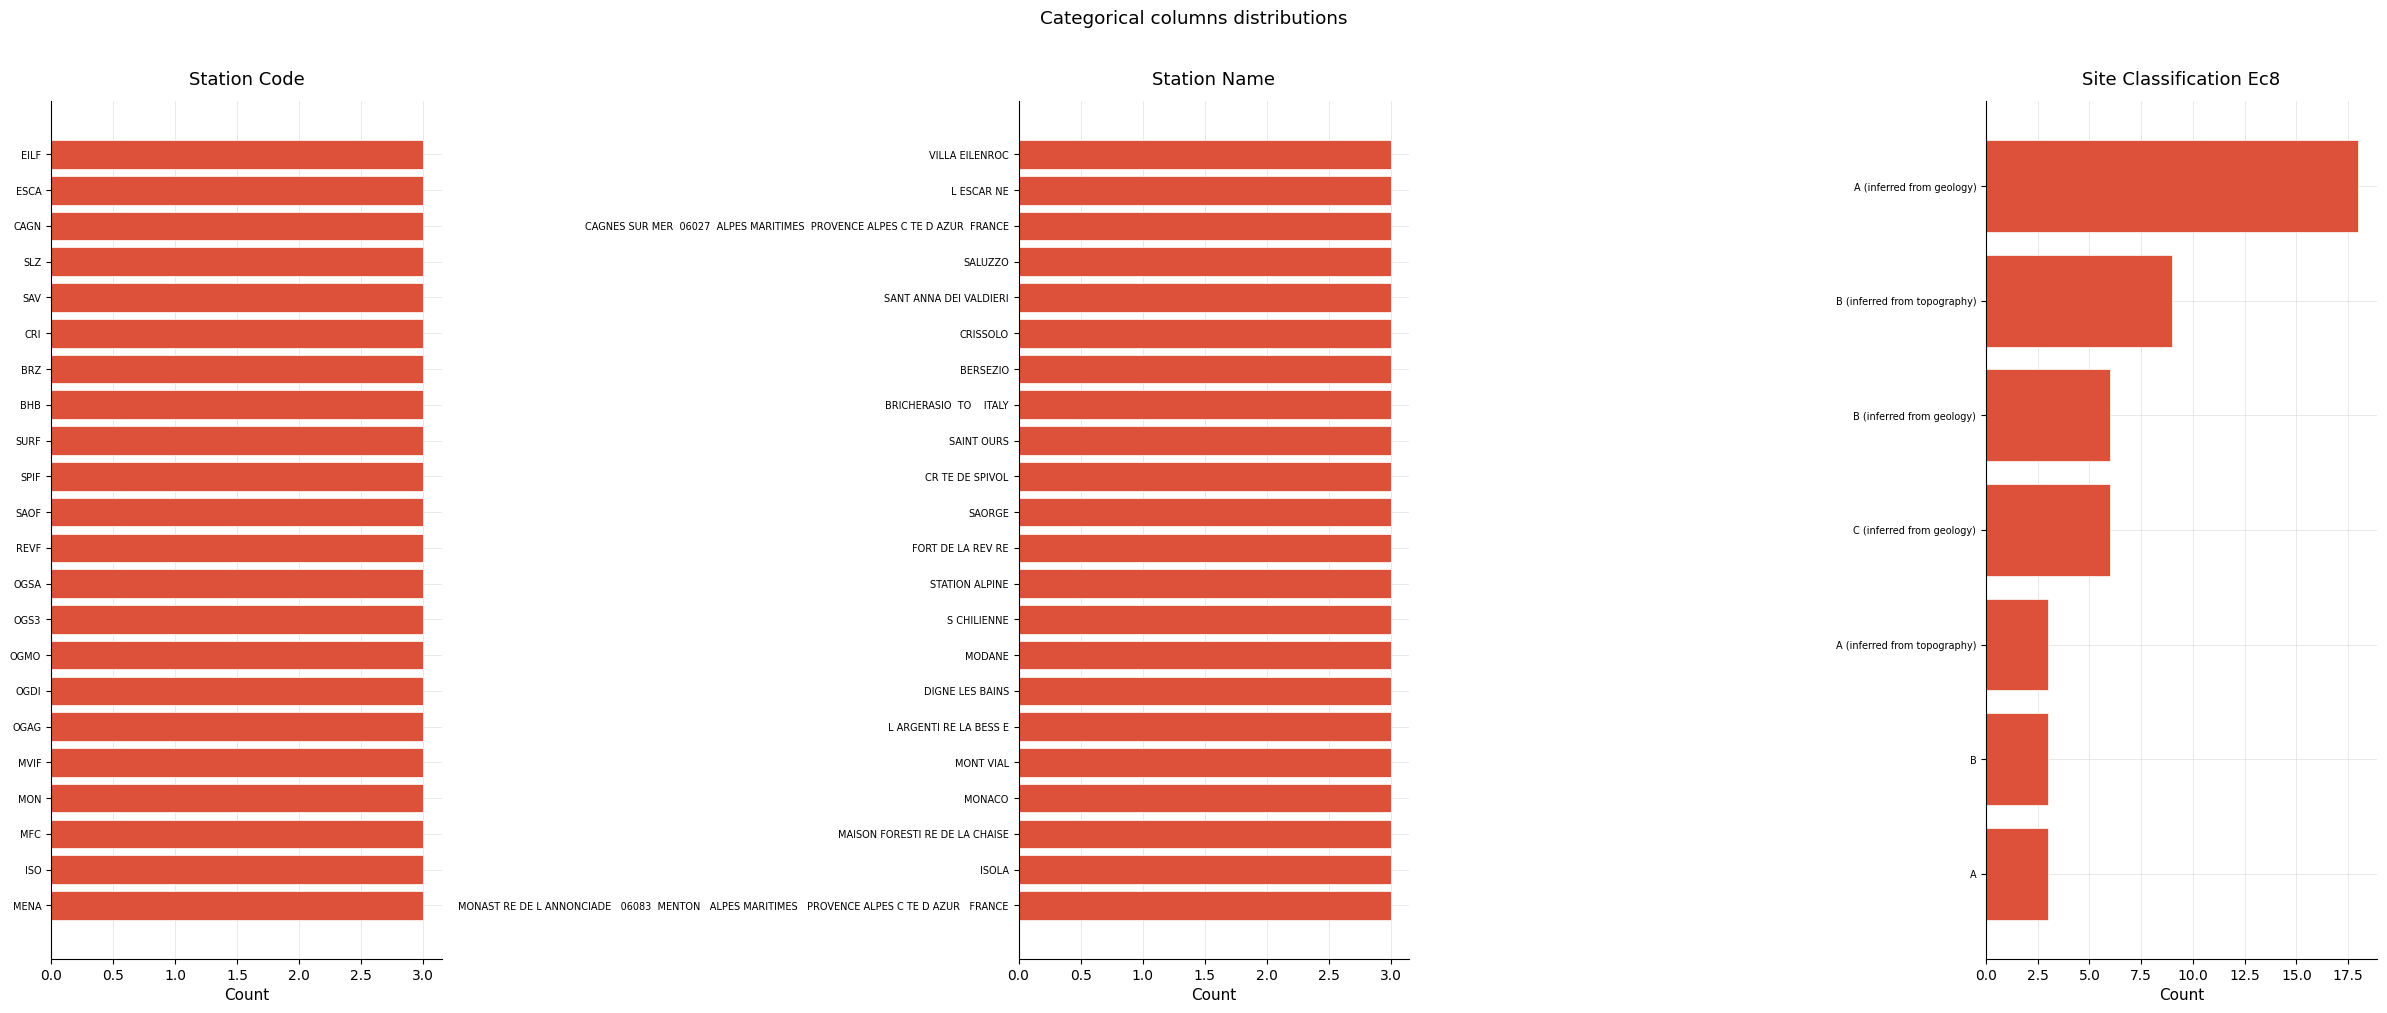

In [ ]:
logger.info("Plotting categorical distributions")

# Find categorical columns automatically
cat_cols = df_meta_var.select_dtypes(include=['object']).columns.tolist()

# Optionally filter out unwanted columns
exclude_cols = ['file']
cat_cols = [col for col in cat_cols if col not in exclude_cols]

logger.info(f"Found {len(cat_cols)} categorical columns: {cat_cols}")

plot_categorical_distributions(
    df_meta_var, 
    cat_cols, 
    output_dir=FIGURES_DIR,
    prefix=DATA_TYPE[:3]
)

### Correlation matrix

Pearson correlation matrix of the numerical variables. Values close to 
$+1$ or $-1$ indicate strong linear relationships, while values close 
to $0$ indicate weak or no linear relationship.

INFO | Computing correlation matrix...
INFO | Correlation matrix shape: (12, 12)
INFO | NaN fraction: 0.000


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/correlation_matrix_acc.pdf


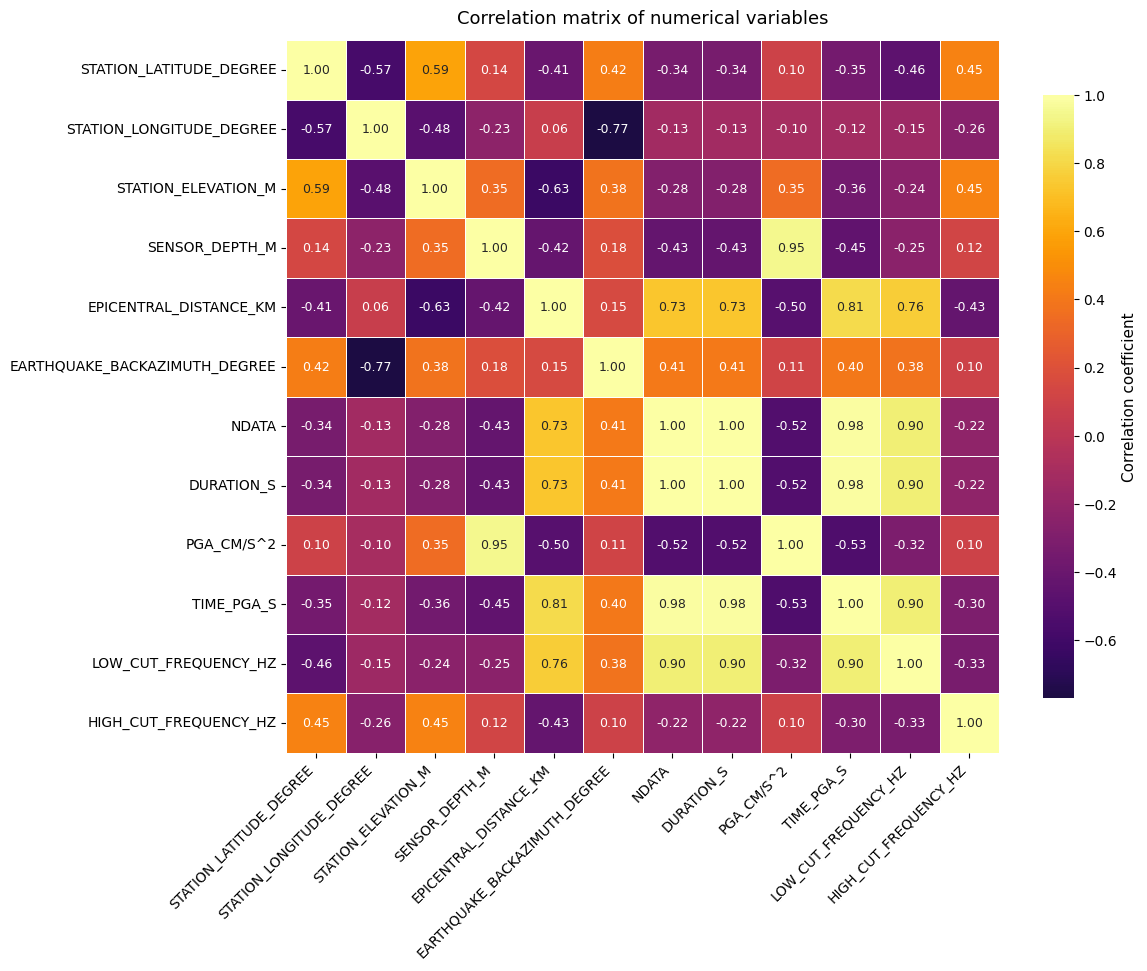

In [ ]:
logger.info("Computing correlation matrix...")
corr = df_meta_var.select_dtypes(include=['float64', 'int64']).corr().round(2)
logger.info(f"Correlation matrix shape: {corr.shape}")
logger.info(f"NaN fraction: {corr.isna().mean().mean():.3f}")

plot_correlation_matrix(
    corr,
    title='Correlation matrix of numerical variables',
    output_path=FIGURES_DIR / f'correlation_matrix_{DATA_TYPE[:3]}.pdf'
)

### Station map

Spatial distribution of the recording stations. Each station is colored 
by its PGA value. The epicenter is marked with a red star.

INFO | Plotting map with 66 stations


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/station_map_acc.pdf


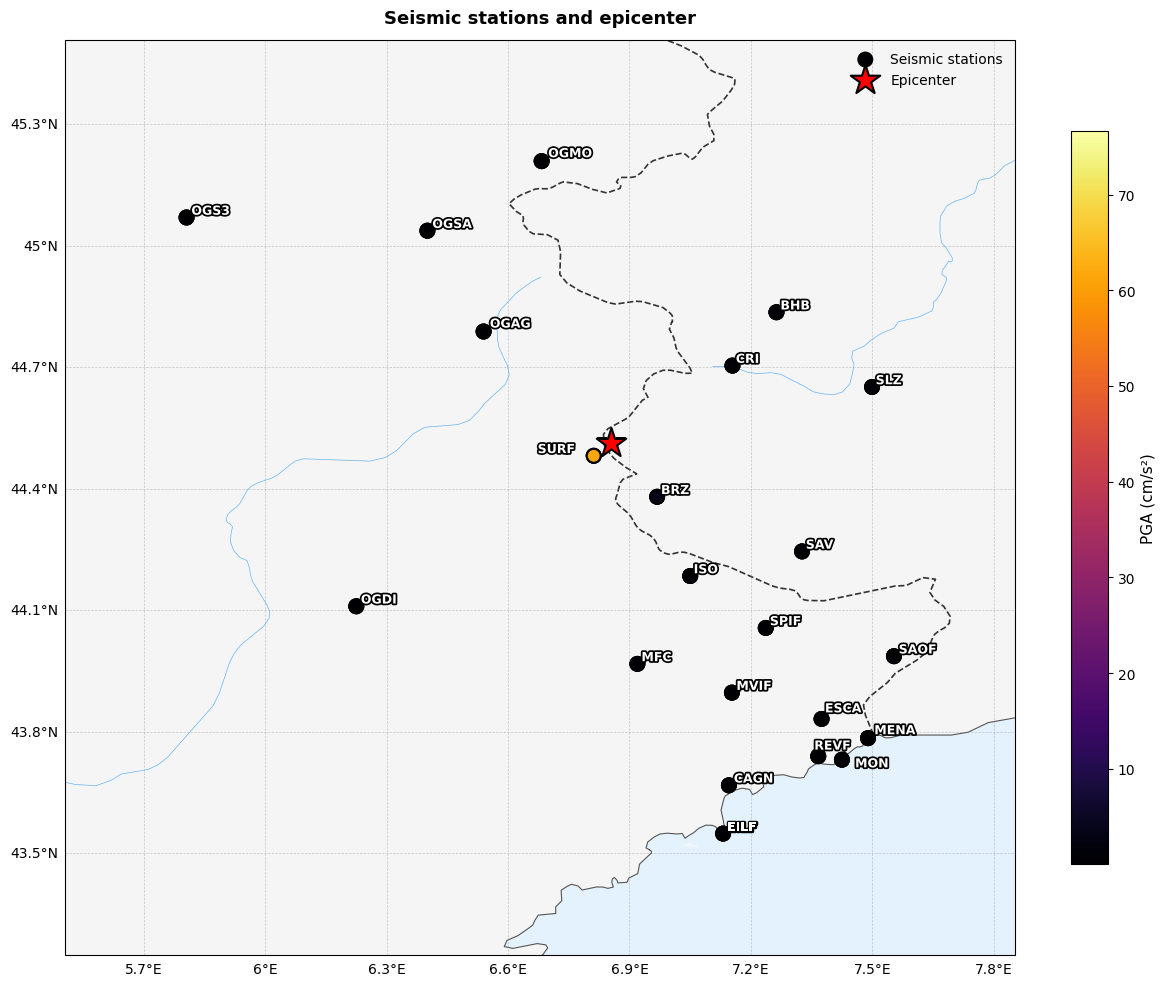

In [ ]:
logger.info(f"Plotting map with {len(df_meta_var)} stations")
event_lat = df_meta_clean['EVENT_LATITUDE_DEGREE'].iloc[0]
event_lon = df_meta_clean['EVENT_LONGITUDE_DEGREE'].iloc[0]

plot_station_map(
    df_meta_var, event_lat, event_lon,
    output_path=FIGURES_DIR / f'station_map_{DATA_TYPE[:3]}.pdf'
)

### Component analysis

Analysis of PGA and signal duration by component (E, N, Z).

In [ ]:
# Map STREAM to component direction
stream_map = {
    'HNZ': 'Z',  # vertical
    'HGZ': 'Z',
    'HNN': 'N',  # north-south
    'HGN': 'N',
    'HN1': 'N',  # ~north, rotated
    'HNE': 'E',  # east-west
    'HGE': 'E',
    'HN2': 'E',  # ~east, rotated
}

df_meta_var['COMPONENT'] = df_meta_var['STREAM'].map(stream_map)
print(df_meta_var['COMPONENT'].value_counts())

colors, colors1 = set_plot_style()
components = ['E', 'N', 'Z']
comp_colors = colors[:3] 
missing_comp = df_meta_var['COMPONENT'].isna().sum()

if missing_comp > 0:
    logger.warning(f"{missing_comp} unmapped components")
else:
    logger.info("All components mapped correctly")

INFO | All components mapped correctly


COMPONENT
E    22
N    22
Z    22
Name: count, dtype: int64


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/pga_by_component_acc.pdf


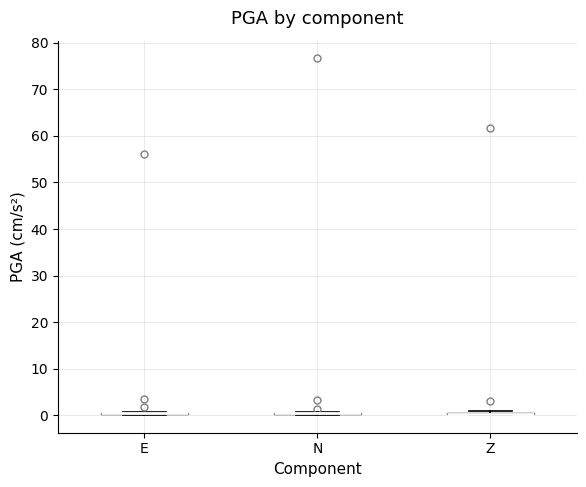

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/pga_vs_distance_by_component_acc.pdf


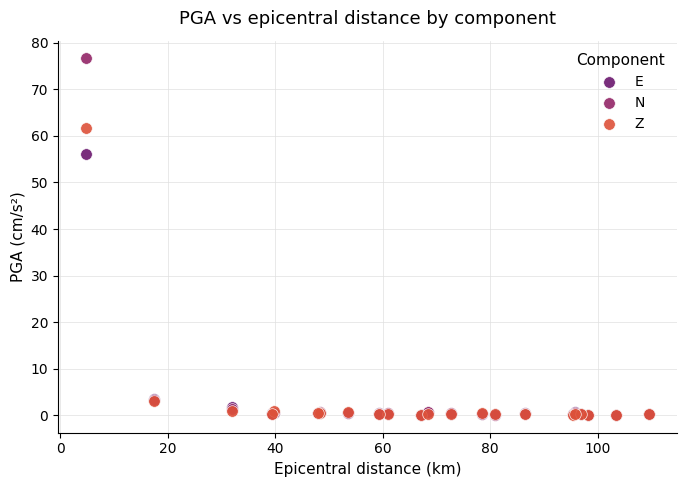

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/duration_by_component_acc.pdf


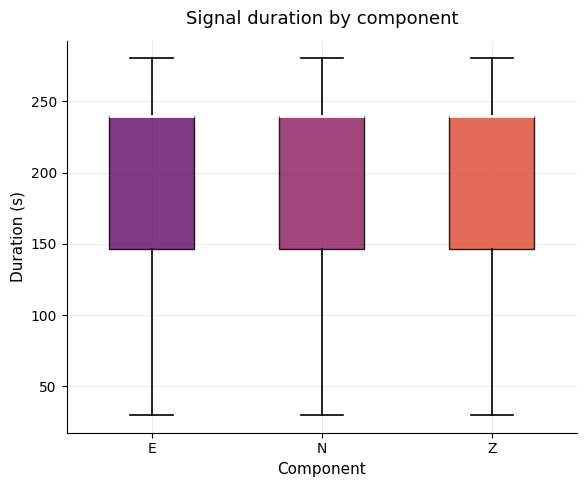

In [ ]:
# Determina quale colonna peak usare
if DATA_TYPE == 'acceleration':
    peak_column = 'PGA_CM/S^2'
elif DATA_TYPE == 'velocity':
    peak_column = 'PGV_CM/S'
elif DATA_TYPE == 'displacement':
    peak_column = 'PGD_CM'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

plot_pga_and_duration_by_component(
    df_meta_var, components, comp_colors, 
    output_dir=FIGURES_DIR,
    prefix=DATA_TYPE[:3],
    peak_column=peak_column
)

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/correlation_matrix_acc_E.pdf


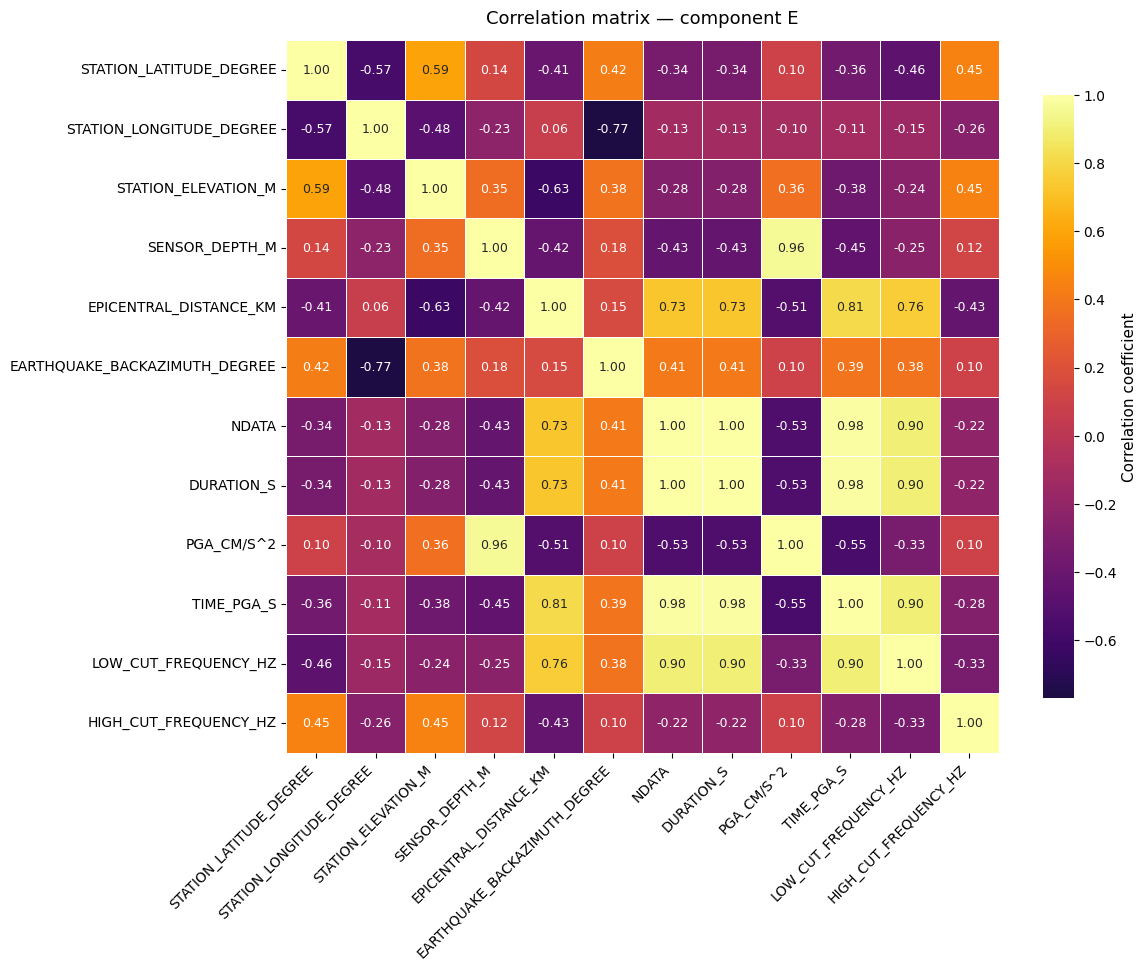

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/correlation_matrix_acc_N.pdf


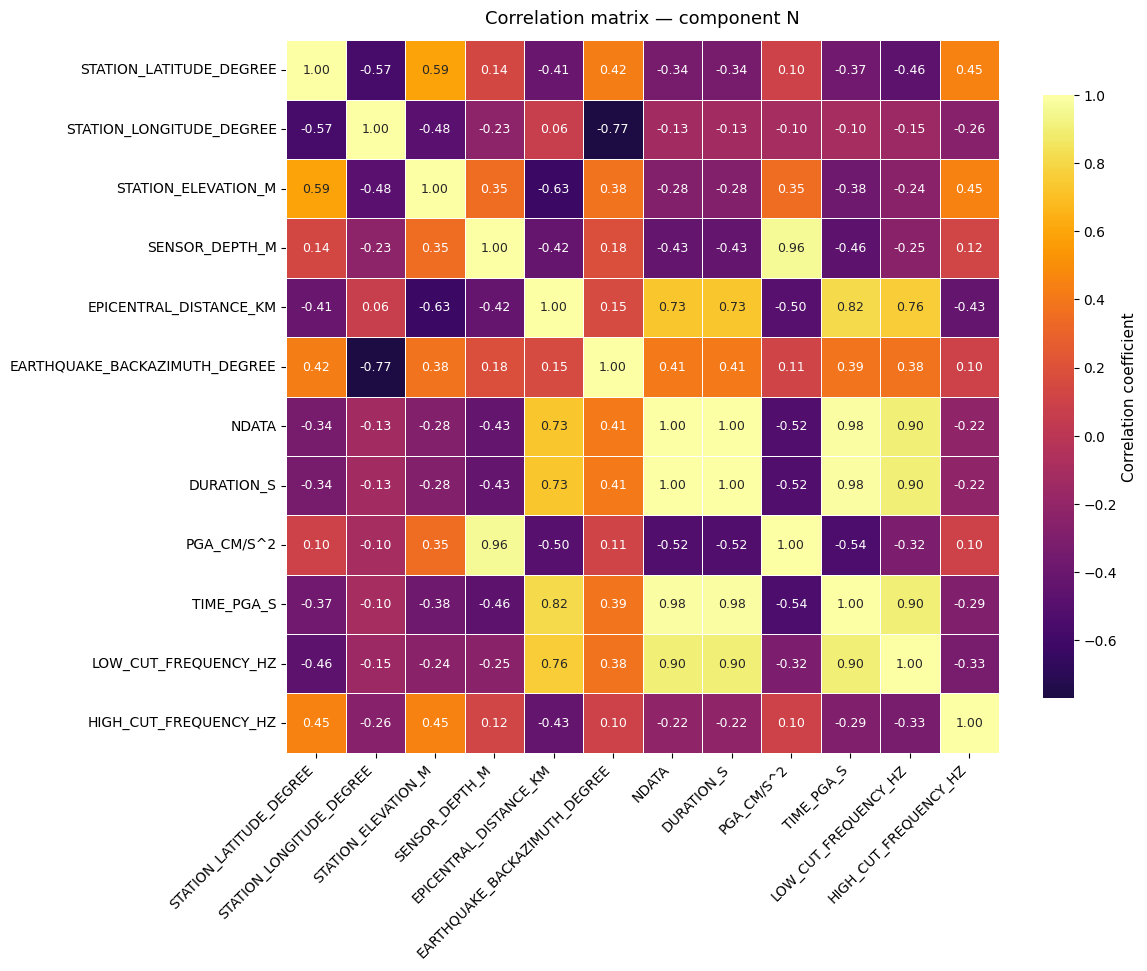

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/correlation_matrix_acc_Z.pdf


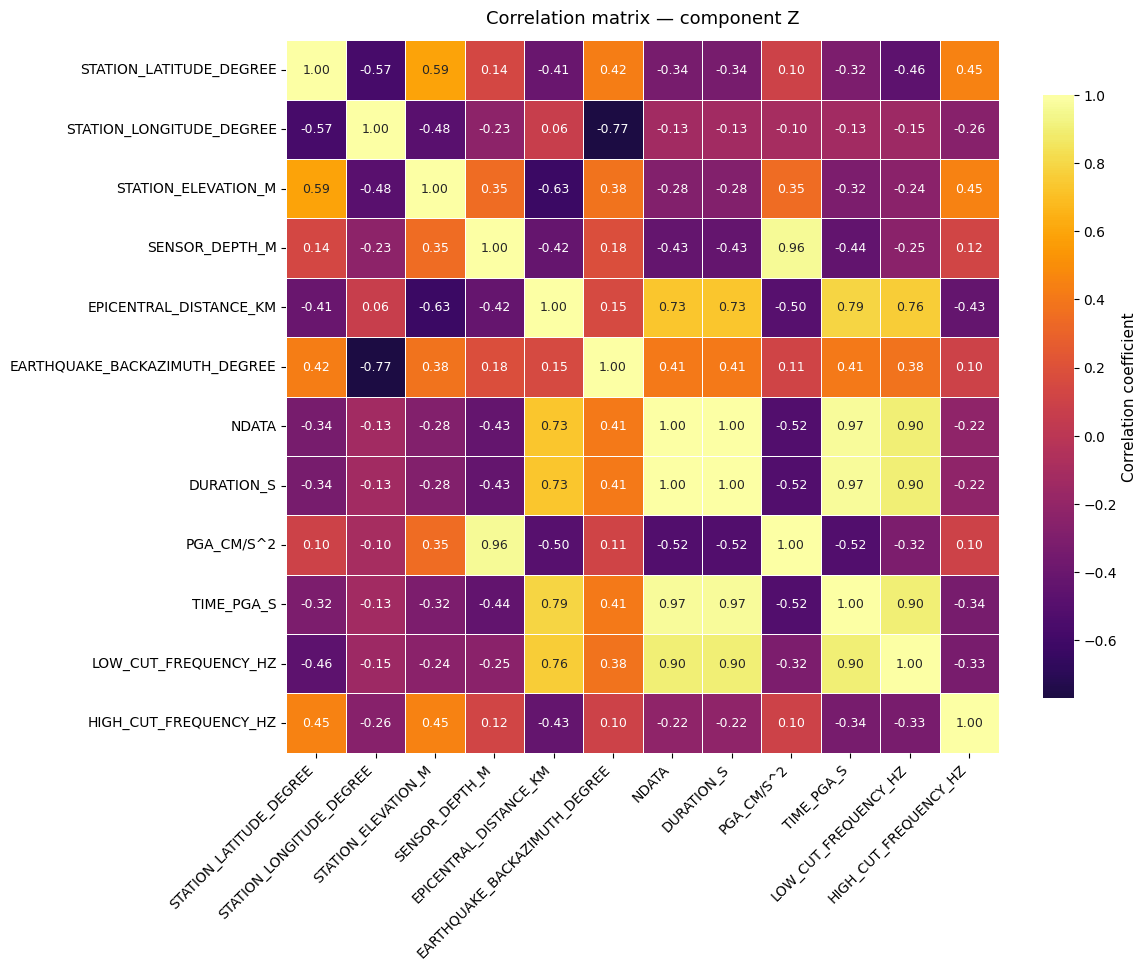

In [ ]:
for comp in ['E', 'N', 'Z']:
    subset = df_meta_var[df_meta_var['COMPONENT'] == comp]
    corr_comp = subset.select_dtypes(include=['float64', 'int64']).corr().round(2)
    plot_correlation_matrix(
        corr_comp,
        title=f'Correlation matrix — component {comp}',
        output_path=FIGURES_DIR / f'correlation_matrix_{DATA_TYPE[:3]}_{comp}.pdf'
    )

## 7. Epicentral distance analysis

Stations are divided into three groups of approximately equal size 
based on their epicentral distance $d$:

- **Near**: $d \leq 48.4$ km
- **Mid**: $53.5 \leq d \leq 78.5$ km  
- **Far**: $80.9 \leq d \leq 109.5$ km

The division is performed using quantile-based binning (`pd.qcut` with $q=3$).

In [ ]:
logger.info("Creating distance groups...")
# Divide stations into 3 equal groups by epicentral distance
df_stations = df_meta_clean.drop_duplicates('STATION_CODE')[['STATION_CODE', 'EPICENTRAL_DISTANCE_KM']].sort_values('EPICENTRAL_DISTANCE_KM')
df_stations['DISTANCE_GROUP'] = pd.qcut(
    df_stations['EPICENTRAL_DISTANCE_KM'],
    q=3,
    labels=['Near', 'Mid', 'Far']
)
for g in ['Near', 'Mid', 'Far']:
    size = len(df_stations[df_stations['DISTANCE_GROUP'] == g])
    
    if size == 0:
        logger.warning(f"Group {g} is empty")
    else:
        logger.info(f"Group {g}: {size} stations")

display(df_stations.groupby('DISTANCE_GROUP', observed=True)['EPICENTRAL_DISTANCE_KM'].describe())
print("\nStations per group:")
display(df_stations.groupby('DISTANCE_GROUP', observed=True)['STATION_CODE'].apply(list))

# Merge back into df_meta_var
df_meta_var = df_meta_var.merge(
    df_stations[['STATION_CODE', 'DISTANCE_GROUP']],
    on='STATION_CODE',
    how='left'
)

# Setup
groups = ['Near', 'Mid', 'Far']
group_colors = [colors[0], colors[1], colors[2]]

INFO | Creating distance groups...
INFO | Group Near: 7 stations
INFO | Group Mid: 7 stations
INFO | Group Far: 8 stations


,count,mean,std,min,25%,50%,75%,max
DISTANCE_GROUP,,,,,,,,
Near,7.0,32.828571,16.272442,4.8,24.7,39.40,43.9,48.4
Mid,7.0,65.771429,8.502885,53.5,60.1,67.20,70.5,78.5
Far,8.0,95.787500,8.952005,80.9,93.1,96.25,99.5,109.5



Stations per group:


DISTANCE_GROUP
Near              [SURF, BRZ, CRI, OGAG, ISO, SAV, BHB]
Mid            [SLZ, SPIF, MFC, OGDI, OGSA, MVIF, OGMO]
Far     [SAOF, ESCA, REVF, MENA, CAGN, MON, OGS3, EILF]
Name: STATION_CODE, dtype: object

### Correlation analysis by distance group

Separate correlation matrices are computed for each distance group 
to investigate whether the linear relationships between variables 
change with epicentral distance.

INFO | Computing correlation matrices by distance group...


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/correlation_matrix_acc_near.pdf


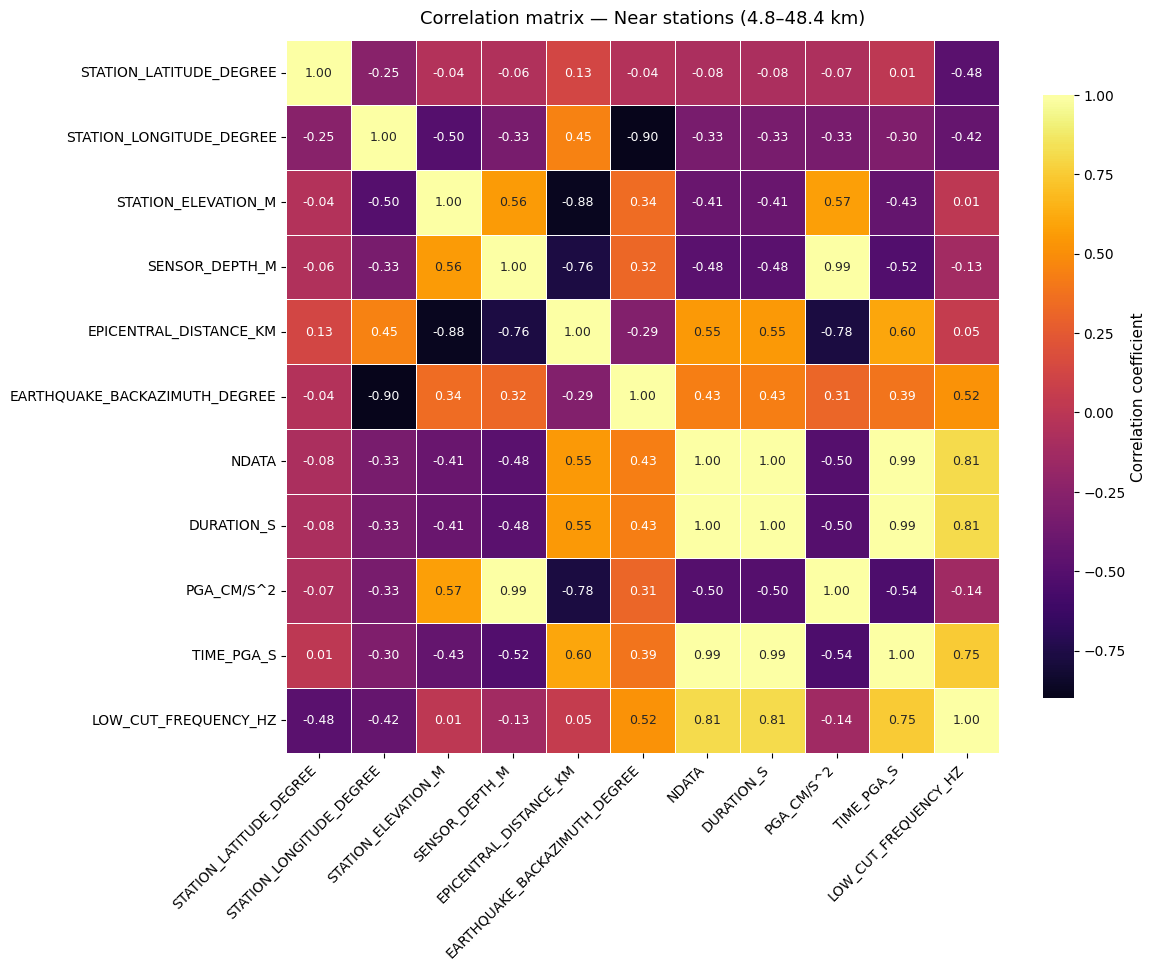

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/correlation_matrix_acc_mid.pdf


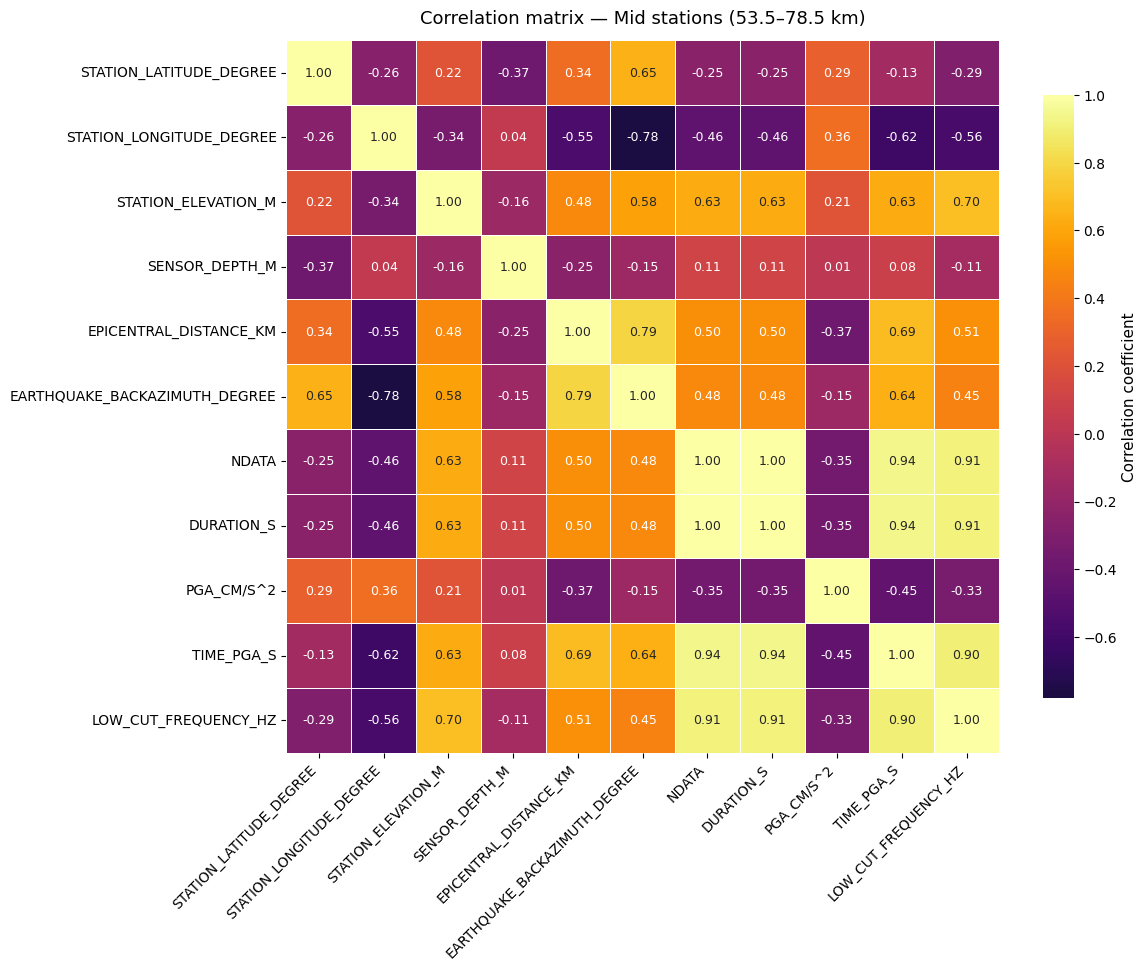

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/correlation_matrix_acc_far.pdf


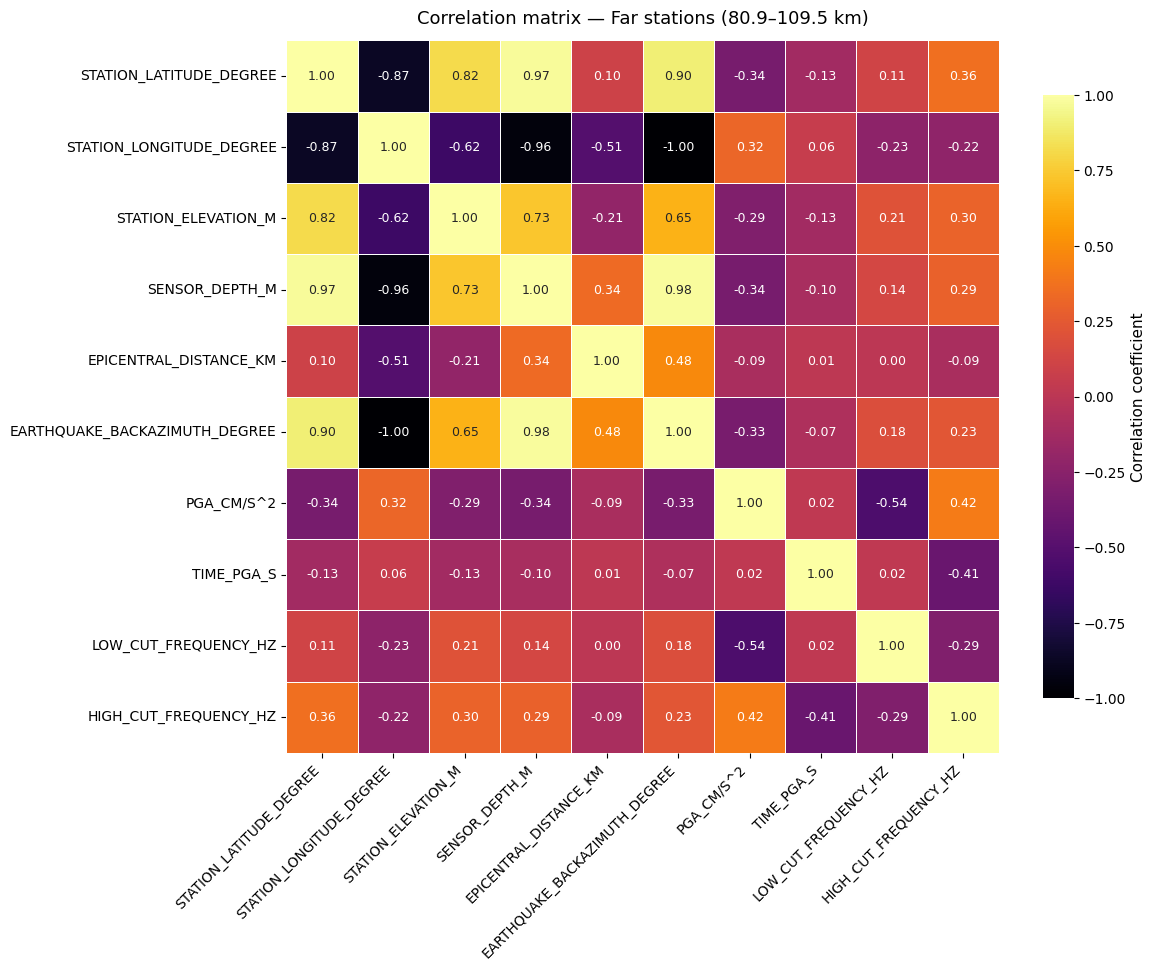

INFO | All distance groups processed


In [ ]:
logger.info("Computing correlation matrices by distance group...")
corr_matrices = {}

for group in groups:
    stations_in_group = df_stations[df_stations['DISTANCE_GROUP'] == group]['STATION_CODE'].values
    df_group = df_meta_var[df_meta_var['STATION_CODE'].isin(stations_in_group)]
    dist_min = df_group['EPICENTRAL_DISTANCE_KM'].min()
    dist_max = df_group['EPICENTRAL_DISTANCE_KM'].max()
    
    numeric_df = df_group.select_dtypes(include=['float64', 'int64'])
    numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]
    corr_matrices[group] = numeric_df.corr().round(2)
    
    plot_correlation_matrix(
        corr_matrices[group],
        title=f'Correlation matrix — {group} stations ({dist_min}–{dist_max} km)',
        output_path=FIGURES_DIR / f'correlation_matrix_{DATA_TYPE[:3]}_{group.lower()}.pdf'
    )

check(len(corr_matrices) == 3, "All distance groups processed")

### Correlation matrix differences by distance group

The difference between correlation matrices of different distance groups 
is computed as:

$$\Delta r_{xy} = r_{xy}^{(g_1)} - r_{xy}^{(g_2)}$$

where $r_{xy}^{(g)}$ is the Pearson correlation coefficient between 
variables $x$ and $y$ for group $g$. Values close to $0$ indicate 
that the correlation is stable across distance groups, while large 
values indicate a significant change.

INFO | Common columns across all groups: 9
INFO | Group pairs to compare: [('Near', 'Mid'), ('Near', 'Far'), ('Mid', 'Far')]


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/corr_diff_acc_near_mid.pdf


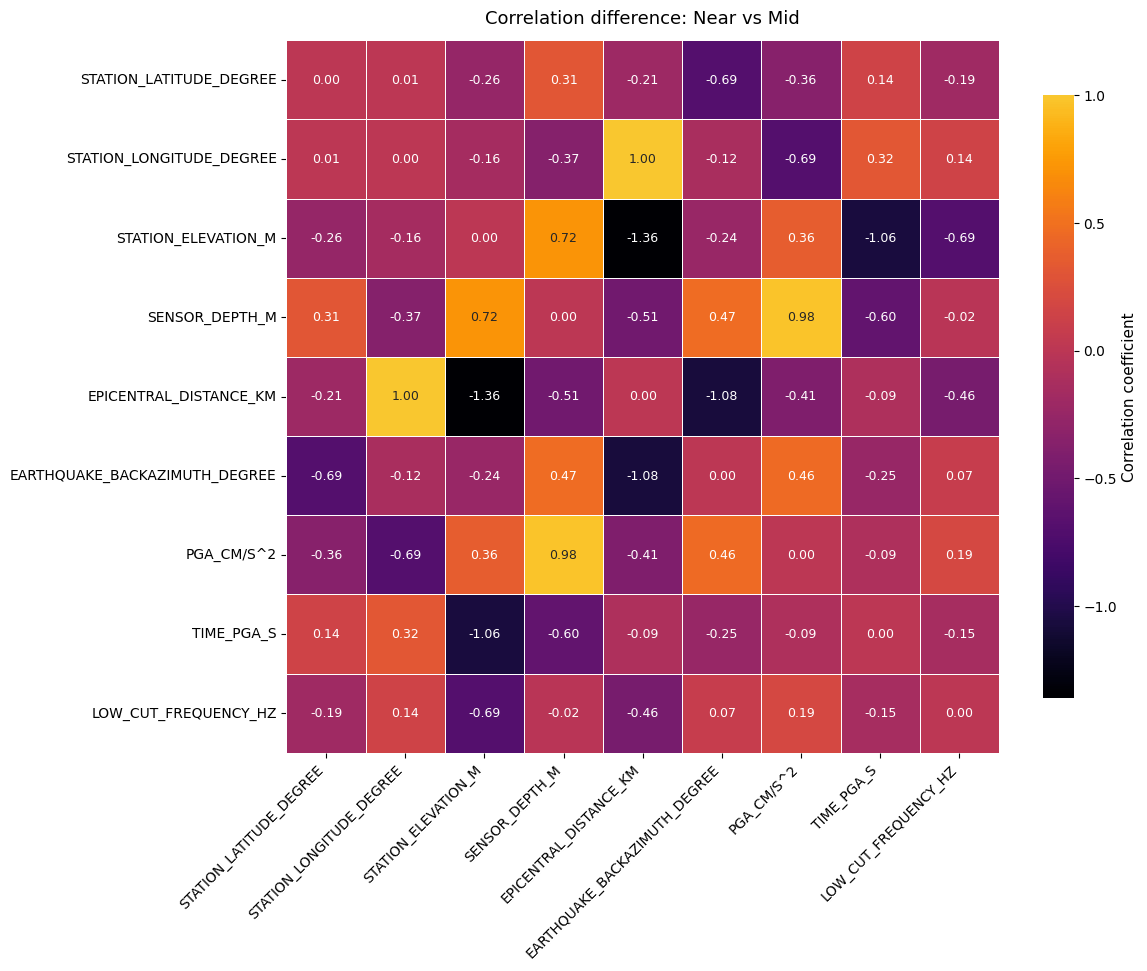

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/corr_diff_acc_near_far.pdf


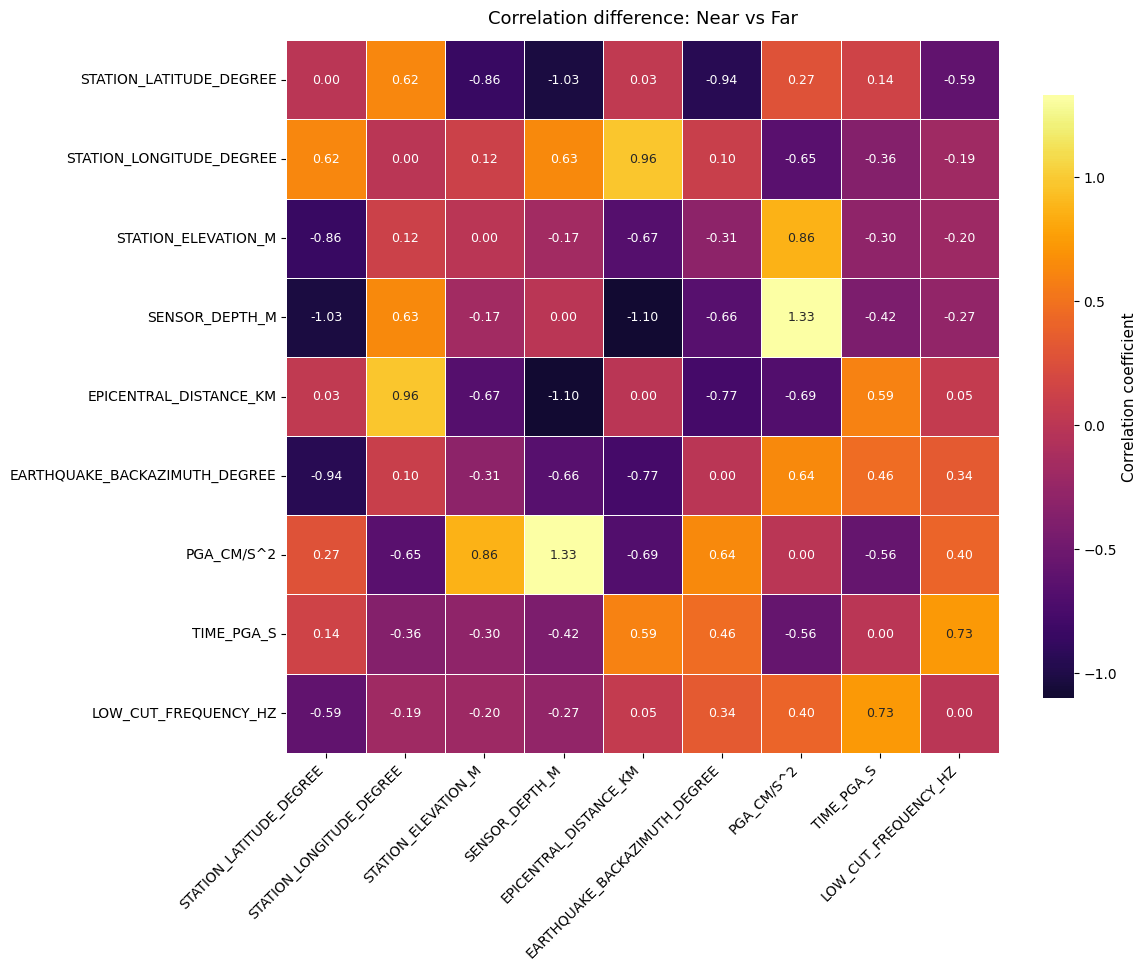

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/corr_diff_acc_mid_far.pdf


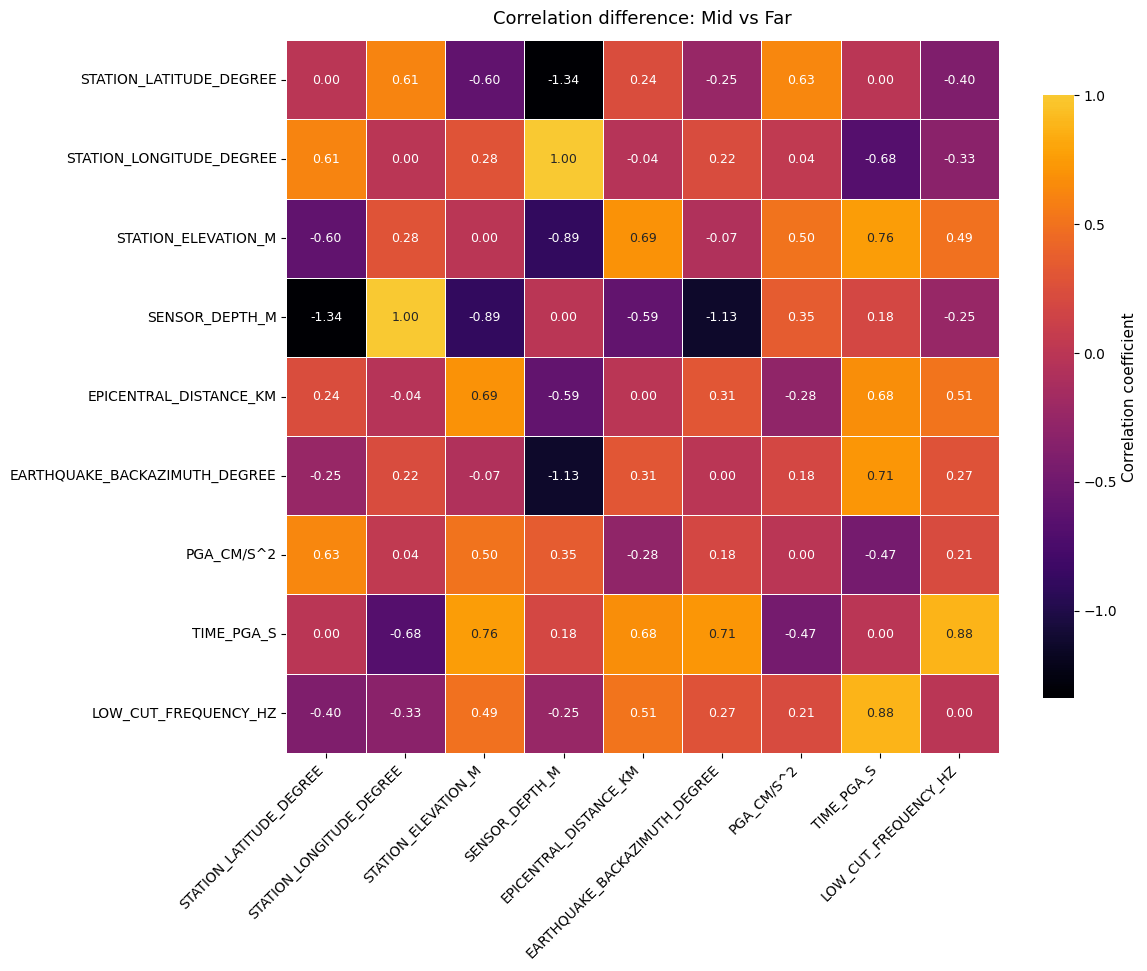

In [ ]:
# Find common columns across all groups
common_cols = corr_matrices['Near'].columns
for group in groups:
    common_cols = common_cols.intersection(corr_matrices[group].columns)

group_pairs = list(combinations(groups, 2))
logger.info(f"Common columns across all groups: {len(common_cols)}")
logger.info(f"Group pairs to compare: {group_pairs}")

for g1, g2 in group_pairs:
    diff = (corr_matrices[g1].loc[common_cols, common_cols] -
            corr_matrices[g2].loc[common_cols, common_cols]).round(2)
    plot_correlation_matrix(
        diff,
        title=f'Correlation difference: {g1} vs {g2}',
        output_path=FIGURES_DIR / f'corr_diff_{DATA_TYPE[:3]}_{g1.lower()}_{g2.lower()}.pdf'
    )

### Statistical significance of correlation differences

The statistical significance of the differences between correlation 
coefficients is assessed using Fisher's z-transformation test. 
For two correlation coefficients $r_1$ and $r_2$ estimated from 
samples of size $n_1$ and $n_2$, the test statistic is:

$$z = \frac{z_1 - z_2}{\sqrt{\frac{1}{n_1 - 3} + \frac{1}{n_2 - 3}}}$$

where $z_i = \text{arctanh}(r_i)$ is Fisher's z-transformation. 
Under the null hypothesis $H_0: r_1 = r_2$, the statistic $z$ 
follows a standard normal distribution. A significance level of 
$\alpha = 0.05$ is used.

INFO | Running Fisher z-test on correlation differences...


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/corr_diff_significant_acc_near_mid.pdf


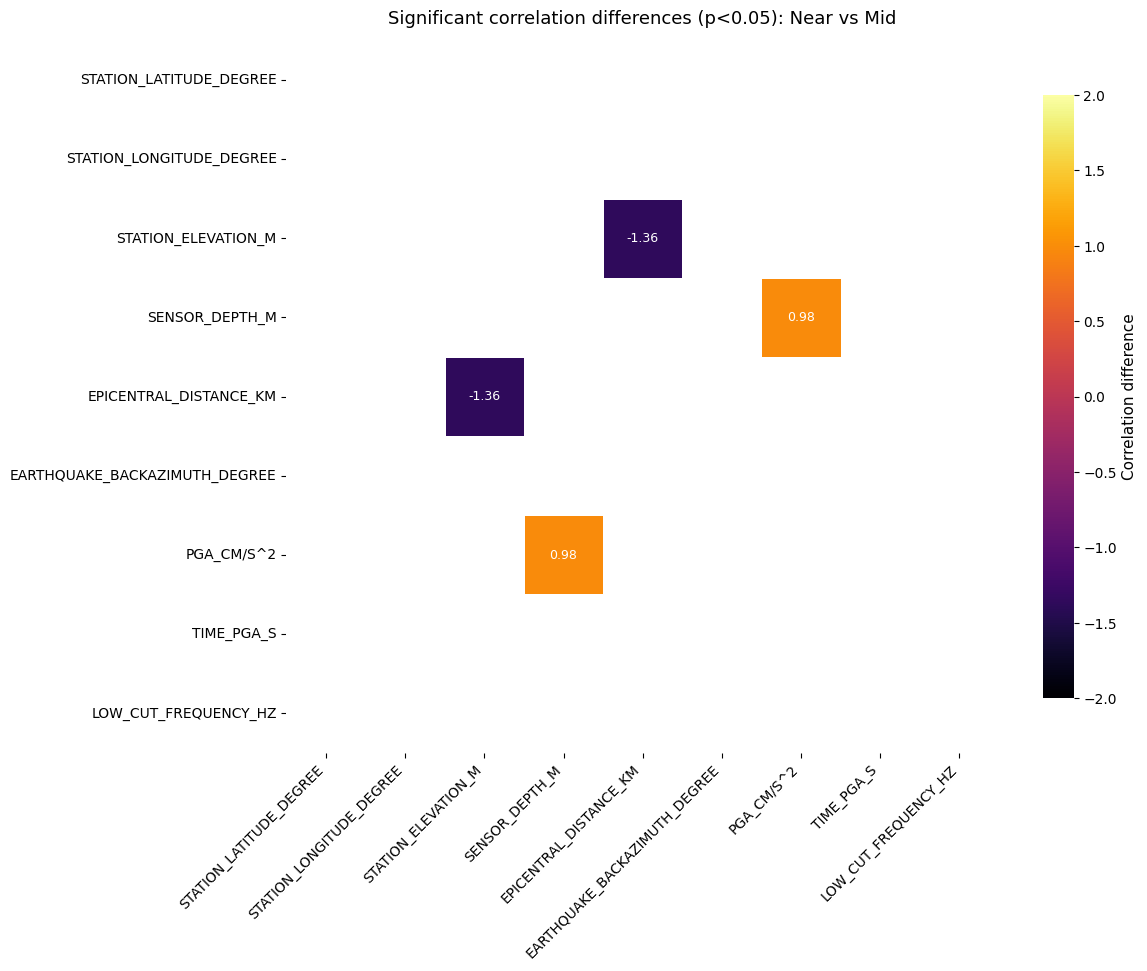

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/corr_diff_significant_acc_near_far.pdf


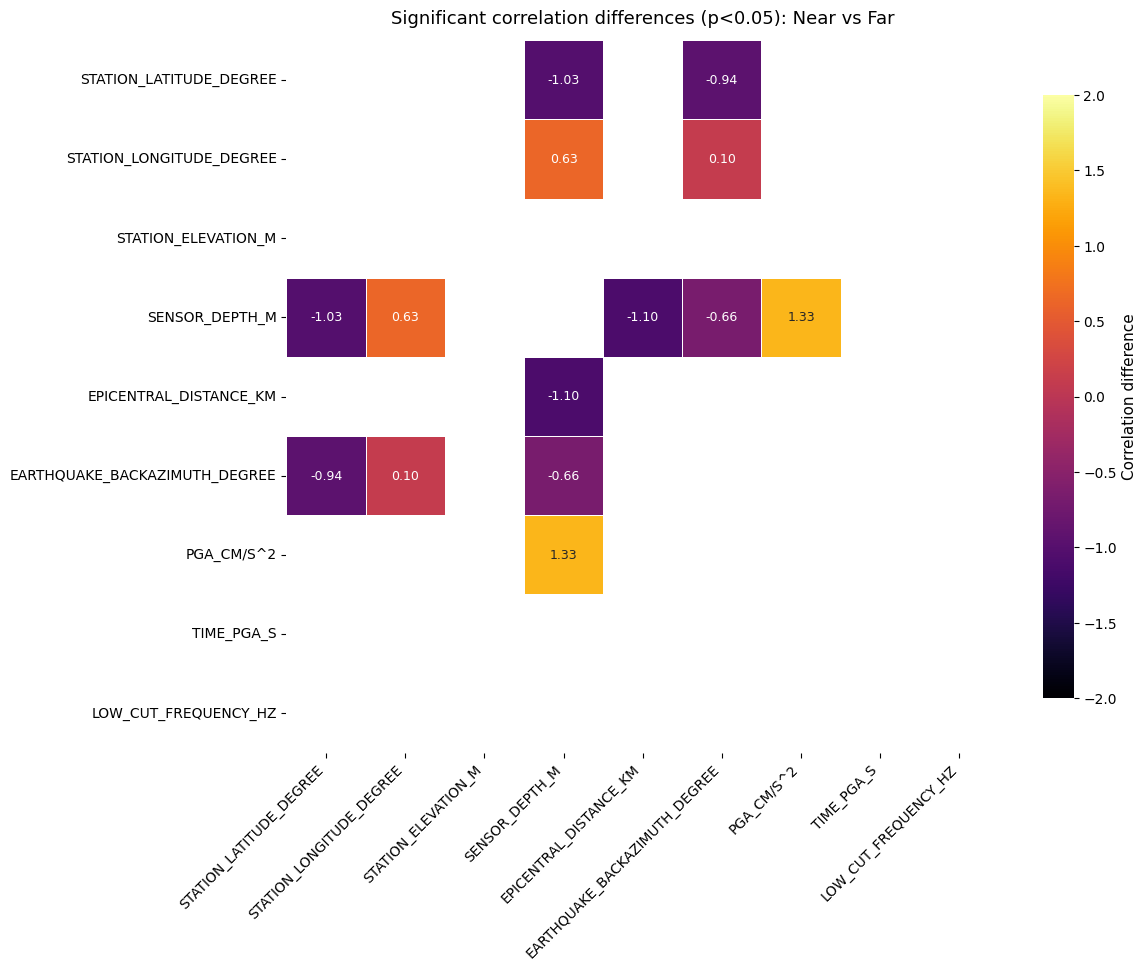

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/corr_diff_significant_acc_mid_far.pdf


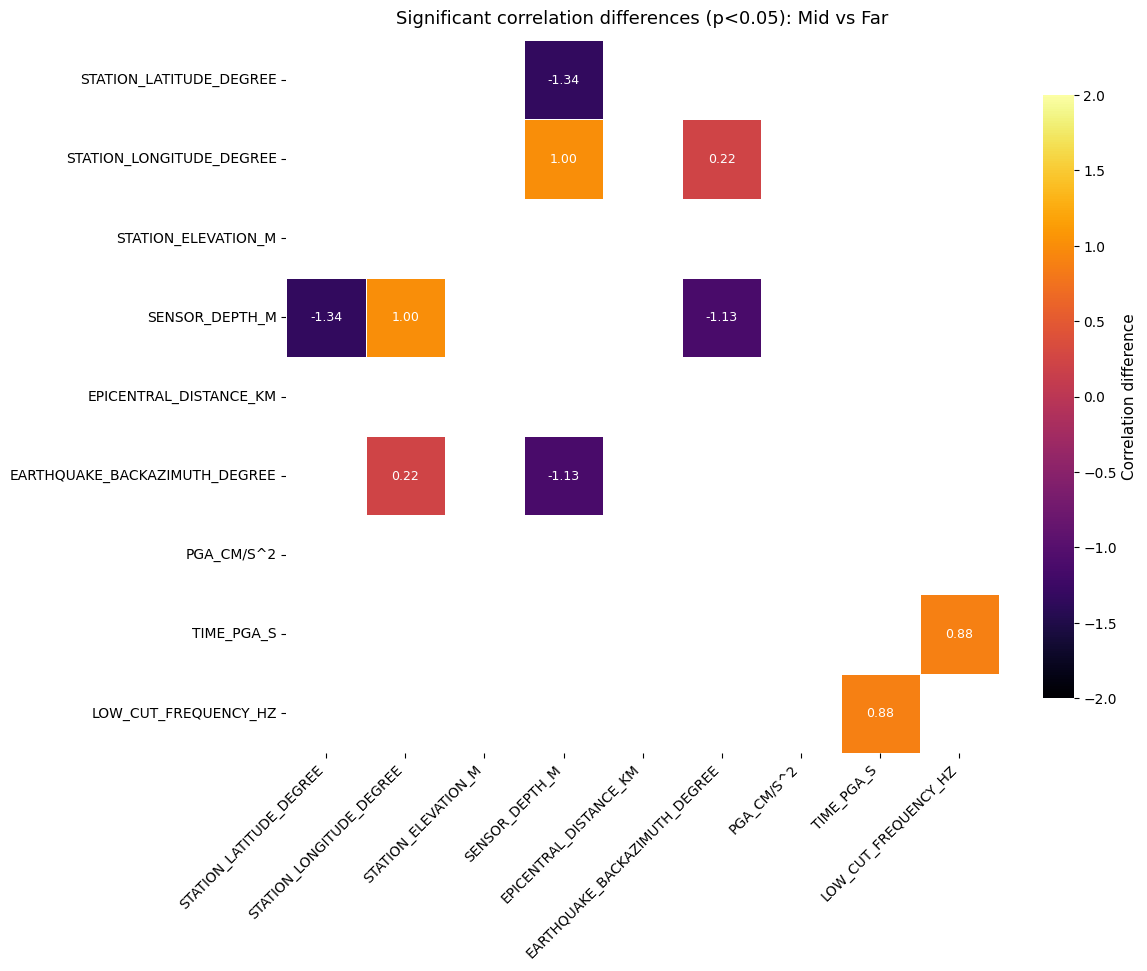

In [ ]:
logger.info("Running Fisher z-test on correlation differences...")

def fisher_z_test(r1, r2, n1, n2):
    """Test if two correlation coefficients are significantly different
    using Fisher's z-transformation."""
    # Fisher z-transformation
    z1 = np.arctanh(np.clip(r1, -0.9999, 0.9999))
    z2 = np.arctanh(np.clip(r2, -0.9999, 0.9999))
    # Standard error
    se = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    # z-score and p-value (two-tailed)
    z = (z1 - z2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return p_value

# Sample sizes per group
n_per_group = {group: len(df_stations[df_stations['DISTANCE_GROUP'] == group]) for group in groups}
alpha = 0.05

for g1, g2 in group_pairs:
    n1, n2 = n_per_group[g1], n_per_group[g2]
    p_matrix = pd.DataFrame(index=common_cols, columns=common_cols, dtype=float)
    
    for col1 in common_cols:
        for col2 in common_cols:
            r1 = corr_matrices[g1].loc[col1, col2]
            r2 = corr_matrices[g2].loc[col1, col2]
            p_matrix.loc[col1, col2] = fisher_z_test(r1, r2, n1, n2)
    
    diff = (corr_matrices[g1].loc[common_cols, common_cols] -
            corr_matrices[g2].loc[common_cols, common_cols]).round(2)
    
    plot_significant_corr_diff(
        diff,
        significant_mask=(p_matrix < alpha),
        title=f'Significant correlation differences (p<{alpha}): {g1} vs {g2}',
        output_path=FIGURES_DIR / f'corr_diff_significant_{DATA_TYPE[:3]}_{g1.lower()}_{g2.lower()}.pdf'
    )

In [ ]:
# Build summary table of significant differences
rows = []
for g1, g2 in group_pairs:
    n1 = n_per_group[g1]
    n2 = n_per_group[g2]
    
    for col1 in common_cols:
        for col2 in common_cols:
            if col1 >= col2:  # avoid duplicates (symmetric matrix)
                continue
            r1 = corr_matrices[g1].loc[col1, col2]
            r2 = corr_matrices[g2].loc[col1, col2]
            p = fisher_z_test(r1, r2, n1, n2)
            diff_val = round(r1 - r2, 2)
            
            if p < alpha:
                rows.append({
                    'Comparison': f'{g1} vs {g2}',
                    'Variable 1': col1,
                    'Variable 2': col2,
                    'Corr. diff.': diff_val,
                    'p-value': round(p, 4)
                })

df_significant = pd.DataFrame(rows).sort_values(
    ['Comparison', 'Corr. diff.'],
    ascending=[True, False],
    key=lambda x: x.abs() if x.dtype != 'object' else x
)
check(len(rows) > 0, "Significant differences detected")
logger.info(f"Found {len(rows)} significant differences")

INFO | Significant differences detected
INFO | Found 14 significant differences


In [ ]:
display(df_significant.style
    .format({'Corr. diff.': '{:.2f}', 'p-value': '{:.4f}'})
    .set_caption('Statistically significant correlation differences by distance group (p < 0.05)')
    .background_gradient(subset=['Corr. diff.'], cmap='inferno')
)

,Comparison,Variable 1,Variable 2,Corr. diff.,p-value
9,Mid vs Far,SENSOR_DEPTH_M,STATION_LATITUDE_DEGREE,-1.34,0.0002
12,Mid vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,SENSOR_DEPTH_M,-1.13,0.0003
10,Mid vs Far,SENSOR_DEPTH_M,STATION_LONGITUDE_DEGREE,1.00,0.0031
13,Mid vs Far,LOW_CUT_FREQUENCY_HZ,TIME_PGA_S,0.88,0.0304
11,Mid vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,STATION_LONGITUDE_DEGREE,0.22,0.0000
8,Near vs Far,PGA_CM/S^2,SENSOR_DEPTH_M,1.33,0.0000
4,Near vs Far,EPICENTRAL_DISTANCE_KM,SENSOR_DEPTH_M,-1.10,0.0441
2,Near vs Far,SENSOR_DEPTH_M,STATION_LATITUDE_DEGREE,-1.03,0.0013
5,Near vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,STATION_LATITUDE_DEGREE,-0.94,0.0242
7,Near vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,SENSOR_DEPTH_M,-0.66,0.0034


In [ ]:
output_path = LATEX_TABLES_DIR / f'corr_diff_table_{DATA_TYPE[:3]}.tex'
latex_table = corr_diff_to_latex(df_significant, output_path=output_path)

if output_path.exists():
    logger.info(f"LaTeX table saved: {output_path}")
else:
    logger.error("LaTeX file not created")

INFO | LaTeX table saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables/corr_diff_table_acc.tex


Saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables/corr_diff_table_acc.tex


### PGA correlation with numerical variables by distance group

The Pearson correlation coefficient between PGA and all other numerical 
variables is computed separately for each distance group and visualized 
as a grouped bar chart.

INFO | Peak correlation computed for 3 groups


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01_metadata/acceleration/pga_correlation_by_distance_acc.pdf


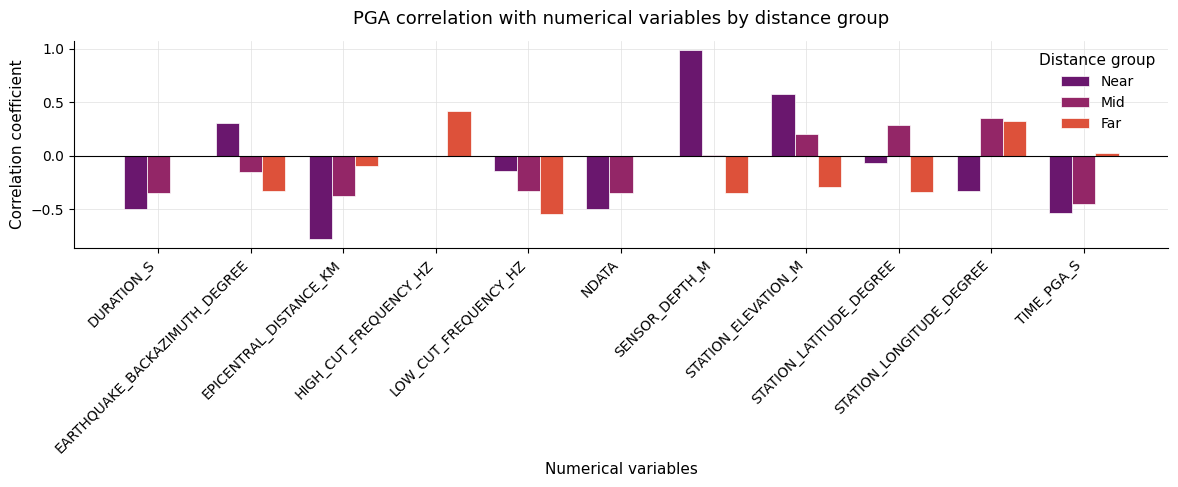

In [ ]:
pga_corrs = {}

for group in groups:
    stations_in_group = df_stations[df_stations['DISTANCE_GROUP'] == group]['STATION_CODE'].values
    df_group = df_meta_var[df_meta_var['STATION_CODE'].isin(stations_in_group)]
    numeric_df = df_group.select_dtypes(include=['float64', 'int64'])
    numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]
    pga_corrs[group] = numeric_df.corr()[peak_column].drop(peak_column)

df_pga_corr = pd.DataFrame(pga_corrs)
logger.info(f"Peak correlation computed for {len(df_pga_corr.columns)} groups")

plot_pga_correlation_by_group(
    df_pga_corr, groups, group_colors, 
    output_dir=FIGURES_DIR,
    prefix=DATA_TYPE[:3],
    peak_column=peak_column
)

## 7. Save preprocessed metadata

The cleaned metadata are saved to parquet format for use in subsequent notebooks.


In [ ]:
logger.info("Saving preprocessed metadata...")

# Save full cleaned metadata (all columns)
output_path = DATA_PROCESSED / f'metadata_clean_{DATA_TYPE[:3]}.parquet'
df_meta_clean.to_parquet(output_path, index=False)
logger.info(f"Saved in: {output_path}")
logger.info(f"  Shape: {df_meta_clean.shape}")

# Save variable-only metadata (for exploratory analysis)
output_path_var = DATA_PROCESSED / f'metadata_variable_{DATA_TYPE[:3]}.parquet'
df_meta_var.to_parquet(output_path_var, index=False)
logger.info(f"Saved in: {output_path_var}")
logger.info(f"  Shape: {df_meta_var.shape}")

print("METADATA PREPROCESSING COMPLETED")
print(f"\nOutput files saved to: {DATA_PROCESSED}")
print(f"  - metadata_clean_{DATA_TYPE[:3]}.parquet ({len(df_meta_clean)} rows, {len(df_meta_clean.columns)} columns)")
print(f"  - metadata_variable_{DATA_TYPE[:3]}.parquet ({len(df_meta_var)} rows, {len(df_meta_var.columns)} columns)")

INFO | Saving preprocessed metadata...
INFO | Saved in: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01_metadata/acceleration/metadata_clean_acc.parquet
INFO |   Shape: (66, 38)
INFO | Saved in: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01_metadata/acceleration/metadata_variable_acc.parquet
INFO |   Shape: (66, 23)


METADATA PREPROCESSING COMPLETED

Output files saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01_metadata/acceleration
  - metadata_clean_acc.parquet (66 rows, 38 columns)
  - metadata_variable_acc.parquet (66 rows, 23 columns)
